In [ ]:
#From a live video web cam, take two frames and find the differences between the frames. Then find if the person is moving forward or backwards.
import cv2
import numpy as np
cap = cv2.VideoCapture(0)
ret, frame1 = cap.read()
ret, frame2 = cap.read()
while cap.isOpened():
    diff = cv2.absdiff(frame1, frame2)

    gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(thresh, None, iterations=3)

        contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    movement = "No Significant Movement"

    for contour in contours:
        if cv2.contourArea(contour) < 1500:
            continue

        x, y, w, h = cv2.boundingRect(contour)
        area = w * h

        cv2.rectangle(frame1, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Store previous area
        if 'prev_area' not in globals():
            prev_area = area

        if area > prev_area + 2000:
            movement = "Moving Forward"
        elif area < prev_area - 2000:
            movement = "Moving Backward"

        prev_area = area

    cv2.putText(frame1, movement, (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0, 0, 255), 2)

    cv2.imshow("Motion Detection", frame1)

    frame1 = frame2
    ret, frame2 = cap.read()

    if cv2.waitKey(40) == 27:
        break

cap.release()
cv2.destroyAllWindows()


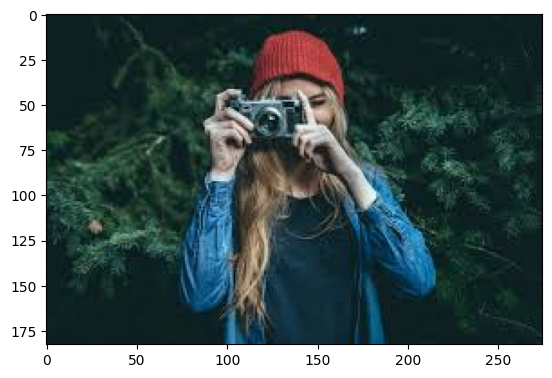

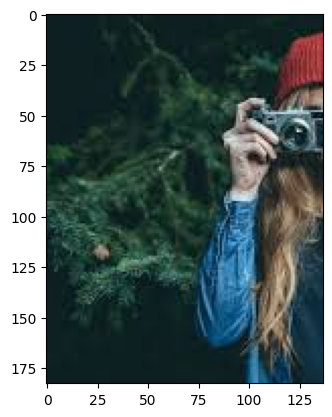

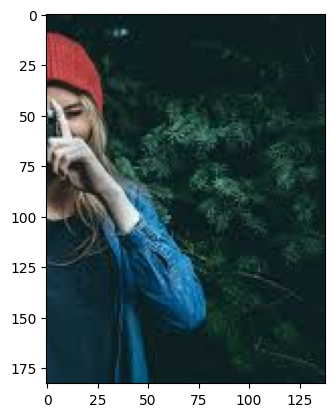

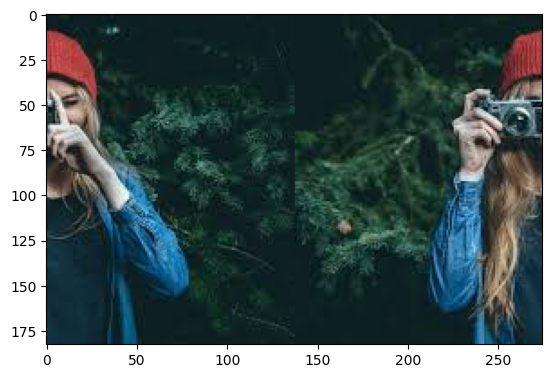

In [12]:
#Split the image into half and reverse the images the second half should come in the beginning and first half in the end
import matplotlib.pyplot as plt
import numpy as np
import cv2
img =cv2.imread("images.jpg")
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

height,width=img.shape[:2]
cropped1 = img[0:height,0:width//2]
plt.imshow(cropped1)
plt.show()

cropped2 = img[0:height,width//2:width]
plt.imshow(cropped2)
plt.show()

merged = np.hstack((cropped2,cropped1))
plt.imshow(merged)
plt.show()